#### 1. Import Libraries & Load Dataset

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = Path(r'F:\Portfollio Projects\Customer Segmentation & RFM Analysis\Dataset\Raw Dataset')

df = pd.read_excel(path / "Online Retail.xlsx")

#### 2. Data Understanding

In [20]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
df[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [10]:
df['Country'].nunique()

38

In [11]:
df['Country'].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [12]:
df['StockCode'].nunique()

4070

In [13]:
df['CustomerID'].nunique()

4372

In [14]:
df['InvoiceNo'].nunique()

25900

In [15]:
df['InvoiceDate'].min()

Timestamp('2010-12-01 08:26:00')

In [16]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [17]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [18]:
df[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'InvoiceDate', 'UnitPrice',
     'CustomerID', 'Country']
].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [19]:
initial_summary = {
    'Total Rows': len(df),
    'Total Columns': df.shape[1],
    'Unique Customers': df['CustomerID'].nunique(),
    'Unique Transactions': df['InvoiceNo'].nunique(),
    'Unique Products': df['StockCode'].nunique(),
    'Unique Countries': df['Country'].nunique(),
    'Start Date': df['InvoiceDate'].min(),
    'End Date': df['InvoiceDate'].max()
}

initial_summary

{'Total Rows': 541909,
 'Total Columns': 8,
 'Unique Customers': 4372,
 'Unique Transactions': 25900,
 'Unique Products': 4070,
 'Unique Countries': 38,
 'Start Date': Timestamp('2010-12-01 08:26:00'),
 'End Date': Timestamp('2011-12-09 12:50:00')}

#### 3. Data Quality Assessment & Data Cleaning

In [28]:
df_clean = df.copy()

In [29]:
quality_summary = pd.DataFrame({
    'Missing Values': df_clean.isnull().sum(),
    'Missing %': (df_clean.isnull().mean() * 100).round(2),
    'Unique Values': df_clean.nunique()
})

quality_summary

,Missing Values,Missing %,Unique Values
InvoiceNo,0,0.00,25900
StockCode,0,0.00,4070
Description,1454,0.27,4223
Quantity,0,0.00,722
InvoiceDate,0,0.00,23260
UnitPrice,0,0.00,1630
CustomerID,135080,24.93,4372
Country,0,0.00,38


In [30]:
df_clean['CustomerID'].isna().sum()

np.int64(135080)

In [31]:
df_clean = df_clean.dropna(subset=['CustomerID'])

In [32]:
df.duplicated().sum()

np.int64(5268)

In [33]:
df_clean = df_clean.drop_duplicates()

In [34]:
cancelled_df = df_clean[df_clean['InvoiceNo'].astype(str).str.startswith('C')]

cancelled_df.shape

(8872, 8)

In [35]:
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]     # ~ -  It flips all the True values to False and vice versa.

In [36]:
df_clean['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(0)

In [37]:
(df_clean['Quantity'] < 0).sum()

np.int64(0)

In [38]:
df_clean[df_clean['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [39]:
(df_clean['UnitPrice'] <= 0).sum()

np.int64(40)

In [40]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [41]:
df_clean['Revenue'] = (df_clean['Quantity'] * df_clean['UnitPrice'])

In [42]:
print("Rows:", len(df_clean))
print("Missing CustomerID:", df_clean['CustomerID'].isna().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Negative Quantity:", (df_clean['Quantity'] < 0).sum())
print("Non-positive UnitPrice:", (df_clean['UnitPrice'] <= 0).sum())
print(
    "Cancellation invoices:",
    df_clean['InvoiceNo'].astype(str).str.startswith('C').sum()
)

Rows: 392692
Missing CustomerID: 0
Duplicate rows: 0
Negative Quantity: 0
Non-positive UnitPrice: 0
Cancellation invoices: 0


In [43]:
cleaning_summary = pd.DataFrame({
    'Metric': [
        'Rows',
        'Missing CustomerID',
        'Duplicate Rows',
        'Negative Quantity',
        'Non-positive UnitPrice'
    ],
    
    'Before Cleaning': [
        len(df),
        df['CustomerID'].isna().sum(),
        df.duplicated().sum(),
        (df['Quantity'] < 0).sum(),
        (df['UnitPrice'] <= 0).sum()
    ],
    
    'After Cleaning': [
        len(df_clean),
        df_clean['CustomerID'].isna().sum(),
        df_clean.duplicated().sum(),
        (df_clean['Quantity'] < 0).sum(),
        (df_clean['UnitPrice'] <= 0).sum()
    ]
})

cleaning_summary

,Metric,Before Cleaning,After Cleaning
0,Rows,541909,392692
1,Missing CustomerID,135080,0
2,Duplicate Rows,5268,0
3,Negative Quantity,10624,0
4,Non-positive UnitPrice,2517,0


In [44]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   Revenue      392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [45]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [46]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


#### 4. Exploratory Data Analysis (EDA)

##### 4.1 Business KPIs

In [47]:
total_revenue = df_clean['Revenue'].sum()
total_customers = df_clean['CustomerID'].nunique()
total_orders = df_clean['InvoiceNo'].nunique()
total_products = df_clean['StockCode'].nunique()
total_units = df_clean['Quantity'].sum()

average_order_value = total_revenue / total_orders
average_customer_value = total_revenue / total_customers

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Customers',
        'Total Orders',
        'Total Products',
        'Total Units Sold',
        'Average Order Value',
        'Average Customer Value'
    ],
    'Value': [
        total_revenue,
        total_customers,
        total_orders,
        total_products,
        total_units,
        average_order_value,
        average_customer_value
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,8.887209e+06
1,Total Customers,4.338000e+03
2,Total Orders,1.853200e+04
3,Total Products,3.665000e+03
4,Total Units Sold,5.152002e+06
5,Average Order Value,4.795602e+02
6,Average Customer Value,2.048688e+03


##### 4.2 Customer Analysis

In [48]:
customer_revenue = (df_clean.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False))
customer_revenue.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

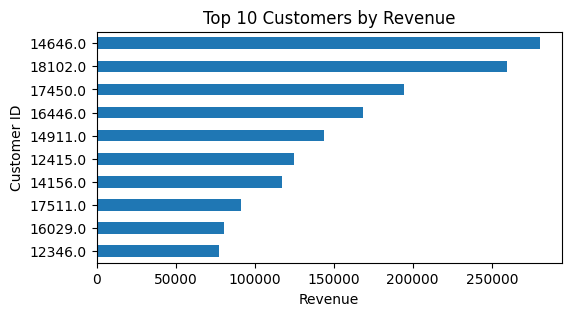

In [50]:
top_customers = customer_revenue.head(10)
plt.figure(figsize=(6, 3))
top_customers.sort_values().plot(kind='barh')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Customer ID')

plt.show()

##### 4.3 Customer Revenue Distribution

In [52]:
customer_revenue_df = (customer_revenue.reset_index().rename(columns={'Revenue': 'CustomerRevenue'}))
customer_revenue_df.head()

,CustomerID,CustomerRevenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17


In [53]:
customer_revenue_df['CustomerRevenue'].describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: CustomerRevenue, dtype: float64

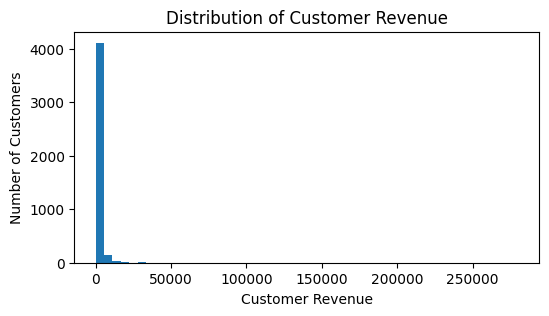

In [57]:
plt.figure(figsize=(6, 3))
plt.hist(
    customer_revenue_df['CustomerRevenue'],
    bins=50
)
plt.title('Distribution of Customer Revenue')
plt.xlabel('Customer Revenue')
plt.ylabel('Number of Customers')

plt.show()

##### 4.4 Pareto Analysis

In [58]:
customer_revenue_df = customer_revenue_df.sort_values(
    'CustomerRevenue',
    ascending=False
)

customer_revenue_df['CumulativeRevenue'] = (
    customer_revenue_df['CustomerRevenue'].cumsum()
)

customer_revenue_df['CumulativeRevenuePct'] = (
    customer_revenue_df['CumulativeRevenue']
    / customer_revenue_df['CustomerRevenue'].sum()
    * 100
)

customer_revenue_df['CustomerRank'] = range(
    1,
    len(customer_revenue_df) + 1
)

customer_revenue_df['CustomerPct'] = (
    customer_revenue_df['CustomerRank']
    / len(customer_revenue_df)
    * 100
)

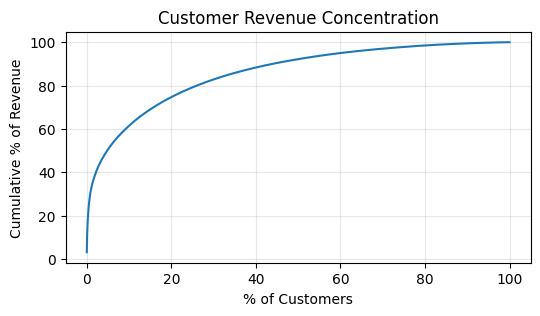

In [59]:
plt.figure(figsize=(6, 3))

plt.plot(
    customer_revenue_df['CustomerPct'],
    customer_revenue_df['CumulativeRevenuePct']
)

plt.xlabel('% of Customers')
plt.ylabel('Cumulative % of Revenue')
plt.title('Customer Revenue Concentration')

plt.grid(alpha=0.3)
plt.show()

In [60]:
def revenue_at_customer_percentile(percent):
    index = int(len(customer_revenue_df) * percent / 100) - 1
    return customer_revenue_df.iloc[index]['CumulativeRevenuePct']

for pct in [1, 5, 10, 20]:
    print(
        f"Top {pct}% customers → "
        f"{revenue_at_customer_percentile(pct):.2f}% of revenue"
    )

Top 1% customers → 31.84% of revenue
Top 5% customers → 50.39% of revenue
Top 10% customers → 61.41% of revenue
Top 20% customers → 74.66% of revenue


##### 4.5 Product Analysis

In [62]:
product_revenue = (df_clean.groupby(['StockCode', 'Description'])['Revenue'].sum().sort_values(ascending=False))

product_revenue.head(10)

StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
22423      REGENCY CAKESTAND 3 TIER              142264.75
85123A     WHITE HANGING HEART T-LIGHT HOLDER    100392.10
85099B     JUMBO BAG RED RETROSPOT                85040.54
23166      MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POST       POSTAGE                                77803.96
47566      PARTY BUNTING                          68785.23
84879      ASSORTED COLOUR BIRD ORNAMENT          56413.03
M          Manual                                 53419.93
23084      RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

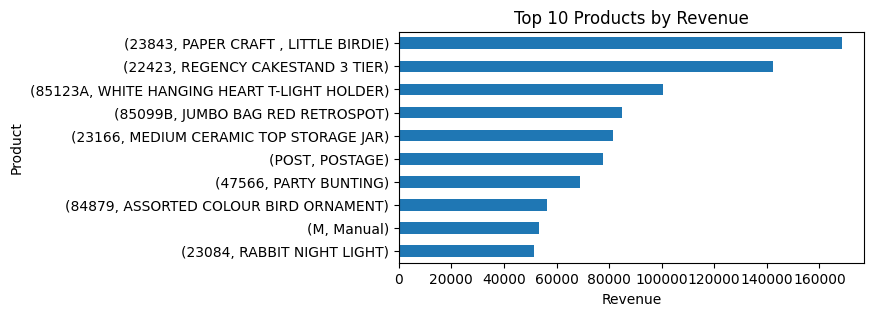

In [63]:
top_products = product_revenue.head(10)

plt.figure(figsize=(6, 3))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.show()

In [64]:
product_quantity = (df_clean.groupby(['StockCode', 'Description'])['Quantity'].sum().sort_values(ascending=False))

product_quantity.head(10)

StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        77916
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
85099B     JUMBO BAG RED RETROSPOT               46078
85123A     WHITE HANGING HEART T-LIGHT HOLDER    36706
84879      ASSORTED COLOUR BIRD ORNAMENT         35263
21212      PACK OF 72 RETROSPOT CAKE CASES       33670
22197      POPCORN HOLDER                        30919
23084      RABBIT NIGHT LIGHT                    27153
22492      MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

##### 4.6 Geographic Analysis

In [65]:
country_revenue = (
    df_clean
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

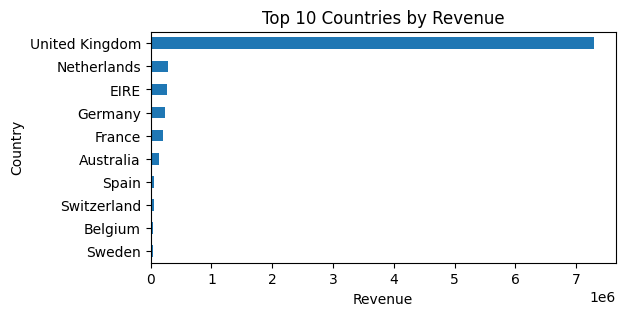

In [66]:
top_countries = country_revenue.head(10)

plt.figure(figsize=(6, 3))

top_countries.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')

plt.show()

In [67]:
country_customers = (df_clean.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False))

country_customers.head(10)

Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64

In [68]:
country_customer_value = (
    df_clean.groupby('Country')
    .agg(
        Revenue=('Revenue', 'sum'),
        Customers=('CustomerID', 'nunique')
    )
)
country_customer_value['RevenuePerCustomer'] = (
    country_customer_value['Revenue']
    / country_customer_value['Customers']
)
country_customer_value.sort_values(
    'RevenuePerCustomer',
    ascending=False
).head(10)

,Revenue,Customers,RevenuePerCustomer
Country,,,
EIRE,265262.46,3,88420.820000
Netherlands,285446.34,9,31716.260000
Singapore,21279.29,1,21279.290000
Australia,138453.81,9,15383.756667
Sweden,38367.83,8,4795.978750
Japan,37416.37,8,4677.046250
Iceland,4310.00,1,4310.000000
Norway,36165.44,10,3616.544000
Switzerland,56443.95,21,2687.807143


##### 4.7 Time-Series Analysis

In [69]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [70]:
monthly_revenue = (df_clean.set_index('InvoiceDate').resample('ME')['Revenue'].sum())

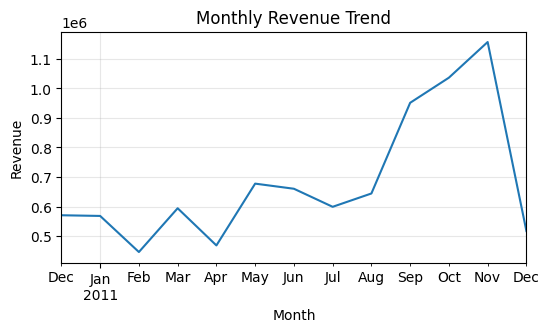

In [71]:
plt.figure(figsize=(6, 3))

monthly_revenue.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(alpha=0.3)
plt.show()

##### 4.8 Monthly Orders

In [72]:
monthly_orders = (
    df_clean
    .set_index('InvoiceDate')
    .resample('ME')['InvoiceNo']
    .nunique()
)

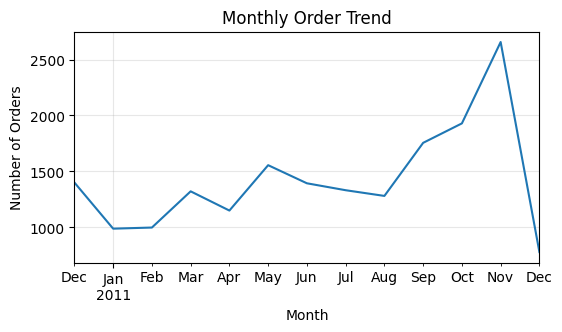

In [73]:
plt.figure(figsize=(6, 3))

monthly_orders.plot()

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.grid(alpha=0.3)
plt.show()

##### 4.9 Monthly Customers

In [74]:
monthly_customers = (
    df_clean
    .set_index('InvoiceDate')
    .resample('ME')['CustomerID']
    .nunique()
)

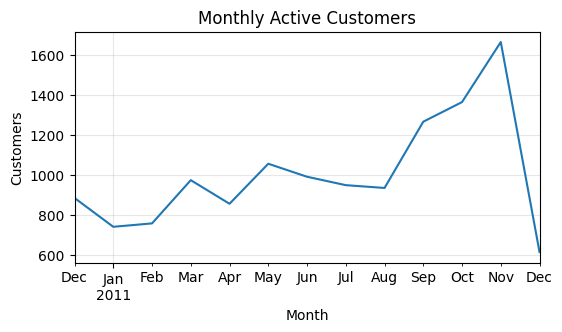

In [75]:
plt.figure(figsize=(6, 3))

monthly_customers.plot()

plt.title('Monthly Active Customers')
plt.xlabel('Month')
plt.ylabel('Customers')

plt.grid(alpha=0.3)
plt.show()

##### 4.10 Average Order Value over time

In [76]:
monthly_aov = (monthly_revenue / monthly_orders)

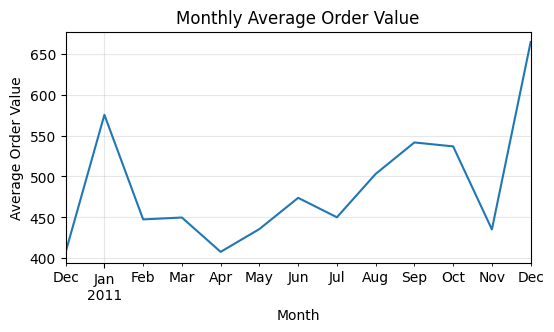

In [77]:
plt.figure(figsize=(6, 3))

monthly_aov.plot()

plt.title('Monthly Average Order Value')
plt.xlabel('Month')
plt.ylabel('Average Order Value')

plt.grid(alpha=0.3)
plt.show()

In [78]:
eda_summary = {
    'Total Revenue': df_clean['Revenue'].sum(),
    'Total Customers': df_clean['CustomerID'].nunique(),
    'Total Orders': df_clean['InvoiceNo'].nunique(),
    'Total Products': df_clean['StockCode'].nunique(),
    'Total Units Sold': df_clean['Quantity'].sum(),
    'Average Order Value': (
        df_clean['Revenue'].sum()
        / df_clean['InvoiceNo'].nunique()
    ),
    'Top Country': country_revenue.index[0],
    'Top Product': product_revenue.index[0][1],
    'Top Customer': customer_revenue.index[0]
}

eda_summary

{'Total Revenue': np.float64(8887208.894000001),
 'Total Customers': 4338,
 'Total Orders': 18532,
 'Total Products': 3665,
 'Total Units Sold': np.int64(5152002),
 'Average Order Value': np.float64(479.56016047917126),
 'Top Country': 'United Kingdom',
 'Top Product': 'PAPER CRAFT , LITTLE BIRDIE',
 'Top Customer': np.float64(14646.0)}

### 5. RFM Analysis

In [79]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [83]:
rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(rfm)

      CustomerID  Recency  Frequency  Monetary
0        12346.0      326          1  77183.60
1        12347.0        2          7   4310.00
2        12348.0       75          4   1797.24
3        12349.0       19          1   1757.55
4        12350.0      310          1    334.40
...          ...      ...        ...       ...
4333     18280.0      278          1    180.60
4334     18281.0      181          1     80.82
4335     18282.0        8          2    178.05
4336     18283.0        4         16   2045.53
4337     18287.0       43          3   1837.28

[4338 rows x 4 columns]


In [85]:
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


In [86]:
print(rfm.isnull().sum())

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64


### 6. RFM Scoring

In [91]:
# RFM Scores

rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    q=5,
    labels=[5, 4, 3, 2, 1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [95]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,326,1,77183.60,1,1,5
1,12347.0,2,7,4310.00,5,5,5
2,12348.0,75,4,1797.24,2,4,4
3,12349.0,19,1,1757.55,4,1,4
4,12350.0,310,1,334.40,1,1,2


In [94]:
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

In [96]:
rfm.dtypes

CustomerID    float64
Recency         int64
Frequency       int64
Monetary      float64
R_Score         int64
F_Score         int64
M_Score         int64
dtype: object

In [97]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

rfm['RFM_Total'] = (
    rfm['R_Score']
    + rfm['F_Score']
    + rfm['M_Score']
)

In [98]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346.0,326,1,77183.60,1,1,5,115,7
1,12347.0,2,7,4310.00,5,5,5,555,15
2,12348.0,75,4,1797.24,2,4,4,244,10
3,12349.0,19,1,1757.55,4,1,4,414,9
4,12350.0,310,1,334.40,1,1,2,112,4


In [99]:
print(rfm['R_Score'].value_counts().sort_index())
print(rfm['F_Score'].value_counts().sort_index())
print(rfm['M_Score'].value_counts().sort_index())

R_Score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64
F_Score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64
M_Score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64


In [100]:
rfm[['R_Score', 'F_Score', 'M_Score', 'RFM_Total']].describe()

,R_Score,F_Score,M_Score,RFM_Total
count,4338.00000,4338.00000,4338.00000,4338.000000
mean,3.00000,3.00000,3.00000,9.000000
std,1.41454,1.41454,1.41454,3.589625
min,1.00000,1.00000,1.00000,3.000000
25%,2.00000,2.00000,2.00000,6.000000
50%,3.00000,3.00000,3.00000,9.000000
75%,4.00000,4.00000,4.00000,12.000000
max,5.00000,5.00000,5.00000,15.000000


In [101]:
rfm.isnull().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
R_Score       0
F_Score       0
M_Score       0
RFM_Score     0
RFM_Total     0
dtype: int64

### 7. Customer Segmentation

In [102]:
def segment_customer(row):
    R = row['R_Score']
    F = row['F_Score']
    M = row['M_Score']

    # Champions
    if R >= 4 and F >= 4 and M >= 4:
        return 'Champions'

    # Loyal Customers
    elif R >= 3 and F >= 4 and M >= 3:
        return 'Loyal Customers'

    # Potential Loyalists
    elif R >= 4 and F >= 2:
        return 'Potential Loyalists'

    # At-Risk Customers
    elif R <= 2 and F >= 3:
        return 'At-Risk Customers'

    # Lost Customers
    elif R <= 2 and F <= 2:
        return 'Lost Customers'
    else:
        return 'Other'

In [103]:
rfm['Segment'] = rfm.apply(segment_customer,axis=1)

In [104]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,12346.0,326,1,77183.60,1,1,5,115,7,Lost Customers
1,12347.0,2,7,4310.00,5,5,5,555,15,Champions
2,12348.0,75,4,1797.24,2,4,4,244,10,At-Risk Customers
3,12349.0,19,1,1757.55,4,1,4,414,9,Other
4,12350.0,310,1,334.40,1,1,2,112,4,Lost Customers


In [105]:
segment_counts = (rfm['Segment'].value_counts())
print(segment_counts)

Segment
Lost Customers         1074
Champions               942
Other                   690
At-Risk Customers       661
Potential Loyalists     511
Loyal Customers         460
Name: count, dtype: int64


In [106]:
segment_percentage = (rfm['Segment'].value_counts(normalize=True).mul(100).round(2))
print(segment_percentage)

Segment
Lost Customers         24.76
Champions              21.72
Other                  15.91
At-Risk Customers      15.24
Potential Loyalists    11.78
Loyal Customers        10.60
Name: proportion, dtype: float64


In [108]:
segment_summary = pd.DataFrame({
    'Customers': segment_counts,
    'Percentage': segment_percentage
})
segment_summary

,Customers,Percentage
Segment,,
Lost Customers,1074,24.76
Champions,942,21.72
Other,690,15.91
At-Risk Customers,661,15.24
Potential Loyalists,511,11.78
Loyal Customers,460,10.60


In [109]:
segment_revenue = (rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False))
segment_revenue

Segment
Champions              5737952.120
Loyal Customers         910756.691
At-Risk Customers       823912.441
Lost Customers          523803.282
Potential Loyalists     508602.610
Other                   382181.750
Name: Monetary, dtype: float64

In [110]:
segment_revenue_pct = (segment_revenue/ segment_revenue.sum()* 100).round(2)
segment_revenue_pct

Segment
Champions              64.56
Loyal Customers        10.25
At-Risk Customers       9.27
Lost Customers          5.89
Potential Loyalists     5.72
Other                   4.30
Name: Monetary, dtype: float64

In [112]:
segment_summary = (
    rfm.groupby('Segment')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Revenue=('Monetary', 'sum'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    )
    .reset_index()
)
segment_summary

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary
0,At-Risk Customers,661,823912.441,150.642965,3.413011,1246.463602
1,Champions,942,5737952.120,12.503185,11.197452,6091.244289
2,Lost Customers,1074,523803.282,216.675047,1.101490,487.712553
3,Loyal Customers,460,910756.691,38.445652,5.289130,1979.905850
4,Other,690,382181.750,45.344928,1.491304,553.886594
5,Potential Loyalists,511,508602.610,16.414873,2.119374,995.308434


In [113]:
segment_summary['Revenue_Percentage'] = (segment_summary['Revenue']/ segment_summary['Revenue'].sum()* 100).round(2)

In [116]:
segment_summary['Revenue_Per_Customer'] = (segment_summary['Revenue']/ segment_summary['Customers'])

In [117]:
segment_summary

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Revenue_Percentage,Revenue_Per_Customer
0,At-Risk Customers,661,823912.441,150.642965,3.413011,1246.463602,9.27,1246.463602
1,Champions,942,5737952.120,12.503185,11.197452,6091.244289,64.56,6091.244289
2,Lost Customers,1074,523803.282,216.675047,1.101490,487.712553,5.89,487.712553
3,Loyal Customers,460,910756.691,38.445652,5.289130,1979.905850,10.25,1979.905850
4,Other,690,382181.750,45.344928,1.491304,553.886594,4.30,553.886594
5,Potential Loyalists,511,508602.610,16.414873,2.119374,995.308434,5.72,995.308434


In [118]:
rfm['Segment'].value_counts()

Segment
Lost Customers         1074
Champions               942
Other                   690
At-Risk Customers       661
Potential Loyalists     511
Loyal Customers         460
Name: count, dtype: int64

In [119]:
rfm[rfm['Segment'] == 'Other'][
    ['CustomerID',
     'R_Score',
     'F_Score',
     'M_Score',
     'RFM_Score']
].head(20)

,CustomerID,R_Score,F_Score,M_Score,RFM_Score
3,12349.0,4,1,4,414
10,12357.0,4,1,5,415
13,12360.0,3,3,5,335
19,12367.0,5,1,1,511
21,12371.0,3,2,4,324
22,12372.0,3,3,4,334
24,12374.0,4,1,3,413
36,12391.0,4,1,2,412
38,12394.0,3,2,4,324
40,12397.0,3,2,5,325


In [ ]:
# rfm.to_csv(path / 'customer_rfm_segmentation.csv',index=False)

### 8. Segment Analysis

In [120]:
segment_summary = (
    rfm.groupby('Segment')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Revenue=('Monetary', 'sum'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    )
    .reset_index()
)

segment_summary

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary
0,At-Risk Customers,661,823912.441,150.642965,3.413011,1246.463602
1,Champions,942,5737952.120,12.503185,11.197452,6091.244289
2,Lost Customers,1074,523803.282,216.675047,1.101490,487.712553
3,Loyal Customers,460,910756.691,38.445652,5.289130,1979.905850
4,Other,690,382181.750,45.344928,1.491304,553.886594
5,Potential Loyalists,511,508602.610,16.414873,2.119374,995.308434


In [121]:
segment_summary['Revenue_Percentage'] = (
    segment_summary['Revenue']
    / segment_summary['Revenue'].sum()
    * 100
)

segment_summary['Revenue_Percentage'] = (
    segment_summary['Revenue_Percentage'].round(2)
)
segment_summary

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Revenue_Percentage
0,At-Risk Customers,661,823912.441,150.642965,3.413011,1246.463602,9.27
1,Champions,942,5737952.120,12.503185,11.197452,6091.244289,64.56
2,Lost Customers,1074,523803.282,216.675047,1.101490,487.712553,5.89
3,Loyal Customers,460,910756.691,38.445652,5.289130,1979.905850,10.25
4,Other,690,382181.750,45.344928,1.491304,553.886594,4.30
5,Potential Loyalists,511,508602.610,16.414873,2.119374,995.308434,5.72


In [123]:
segment_summary['Customer_Percentage'] = (segment_summary['Customers']/ segment_summary['Customers'].sum()* 100).round(2)

In [124]:
segment_summary['Revenue_Per_Customer'] = (segment_summary['Revenue']/ segment_summary['Customers'])

In [125]:
segment_summary['Revenue_Per_Customer'] = (segment_summary['Revenue_Per_Customer'].round(2))

In [126]:
segment_summary = (
    rfm.groupby('Segment')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Revenue=('Monetary', 'sum'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    )
    .reset_index()
)

segment_summary['Customer_Percentage'] = (
    segment_summary['Customers']
    / segment_summary['Customers'].sum()
    * 100
).round(2)

segment_summary['Revenue_Percentage'] = (
    segment_summary['Revenue']
    / segment_summary['Revenue'].sum()
    * 100
).round(2)

segment_summary['Revenue_Per_Customer'] = (
    segment_summary['Revenue']
    / segment_summary['Customers']
).round(2)

segment_summary

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage,Revenue_Percentage,Revenue_Per_Customer
0,At-Risk Customers,661,823912.441,150.642965,3.413011,1246.463602,15.24,9.27,1246.46
1,Champions,942,5737952.120,12.503185,11.197452,6091.244289,21.72,64.56,6091.24
2,Lost Customers,1074,523803.282,216.675047,1.101490,487.712553,24.76,5.89,487.71
3,Loyal Customers,460,910756.691,38.445652,5.289130,1979.905850,10.60,10.25,1979.91
4,Other,690,382181.750,45.344928,1.491304,553.886594,15.91,4.30,553.89
5,Potential Loyalists,511,508602.610,16.414873,2.119374,995.308434,11.78,5.72,995.31


In [127]:
segment_summary[['Segment','Avg_Recency','Avg_Frequency','Avg_Monetary']]

,Segment,Avg_Recency,Avg_Frequency,Avg_Monetary
0,At-Risk Customers,150.642965,3.413011,1246.463602
1,Champions,12.503185,11.197452,6091.244289
2,Lost Customers,216.675047,1.101490,487.712553
3,Loyal Customers,38.445652,5.289130,1979.905850
4,Other,45.344928,1.491304,553.886594
5,Potential Loyalists,16.414873,2.119374,995.308434


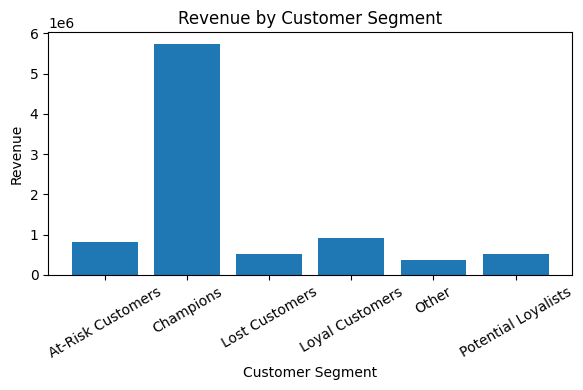

In [130]:
plt.figure(figsize=(6, 4))

plt.bar(
    segment_summary['Segment'],
    segment_summary['Revenue']
)

plt.title('Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [131]:
segment_summary[['Segment','Customer_Percentage','Revenue_Percentage']] #Champions have the highest revenu

,Segment,Customer_Percentage,Revenue_Percentage
0,At-Risk Customers,15.24,9.27
1,Champions,21.72,64.56
2,Lost Customers,24.76,5.89
3,Loyal Customers,10.60,10.25
4,Other,15.91,4.30
5,Potential Loyalists,11.78,5.72


In [132]:
segment_summary.sort_values('Revenue',ascending=False)   # Which segments currently contribute the most revenue?

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage,Revenue_Percentage,Revenue_Per_Customer
1,Champions,942,5737952.120,12.503185,11.197452,6091.244289,21.72,64.56,6091.24
3,Loyal Customers,460,910756.691,38.445652,5.289130,1979.905850,10.60,10.25,1979.91
0,At-Risk Customers,661,823912.441,150.642965,3.413011,1246.463602,15.24,9.27,1246.46
2,Lost Customers,1074,523803.282,216.675047,1.101490,487.712553,24.76,5.89,487.71
5,Potential Loyalists,511,508602.610,16.414873,2.119374,995.308434,11.78,5.72,995.31
4,Other,690,382181.750,45.344928,1.491304,553.886594,15.91,4.30,553.89


In [133]:
segment_summary.sort_values('Customers',ascending=False)   
# Where is the largest portion of the customer base?

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage,Revenue_Percentage,Revenue_Per_Customer
2,Lost Customers,1074,523803.282,216.675047,1.101490,487.712553,24.76,5.89,487.71
1,Champions,942,5737952.120,12.503185,11.197452,6091.244289,21.72,64.56,6091.24
4,Other,690,382181.750,45.344928,1.491304,553.886594,15.91,4.30,553.89
0,At-Risk Customers,661,823912.441,150.642965,3.413011,1246.463602,15.24,9.27,1246.46
5,Potential Loyalists,511,508602.610,16.414873,2.119374,995.308434,11.78,5.72,995.31
3,Loyal Customers,460,910756.691,38.445652,5.289130,1979.905850,10.60,10.25,1979.91


In [134]:
segment_summary.sort_values('Revenue_Per_Customer',ascending=False) 
# Which segment has the highest average revenue per customer?

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage,Revenue_Percentage,Revenue_Per_Customer
1,Champions,942,5737952.120,12.503185,11.197452,6091.244289,21.72,64.56,6091.24
3,Loyal Customers,460,910756.691,38.445652,5.289130,1979.905850,10.60,10.25,1979.91
0,At-Risk Customers,661,823912.441,150.642965,3.413011,1246.463602,15.24,9.27,1246.46
5,Potential Loyalists,511,508602.610,16.414873,2.119374,995.308434,11.78,5.72,995.31
4,Other,690,382181.750,45.344928,1.491304,553.886594,15.91,4.30,553.89
2,Lost Customers,1074,523803.282,216.675047,1.101490,487.712553,24.76,5.89,487.71


In [135]:
at_risk = rfm[rfm['Segment'] == 'At-Risk Customers']

In [137]:
at_risk_summary = {
    'Customers': at_risk['CustomerID'].nunique(),
    'Revenue': at_risk['Monetary'].sum(),
    'Average Revenue': at_risk['Monetary'].mean(),
    'Average Frequency': at_risk['Frequency'].mean(),
    'Average Recency': at_risk['Recency'].mean()
}

at_risk_summary
#How much customer value is currently associated with the At-Risk segment?

{'Customers': 661,
 'Revenue': np.float64(823912.4410000001),
 'Average Revenue': np.float64(1246.463602118003),
 'Average Frequency': np.float64(3.4130105900151286),
 'Average Recency': np.float64(150.642965204236)}

In [138]:
lost = rfm[rfm['Segment'] == 'Lost Customers']

In [140]:
lost_summary = {
    'Customers': lost['CustomerID'].nunique(),
    'Revenue': lost['Monetary'].sum(),
    'Average Revenue': lost['Monetary'].mean(),
    'Average Frequency': lost['Frequency'].mean(),
    'Average Recency': lost['Recency'].mean()
}
lost_summary

{'Customers': 1074,
 'Revenue': np.float64(523803.282),
 'Average Revenue': np.float64(487.7125530726257),
 'Average Frequency': np.float64(1.101489757914339),
 'Average Recency': np.float64(216.67504655493482)}

In [141]:
champions = rfm[rfm['Segment'] == 'Champions']

In [142]:
champion_summary = {
    'Customers': champions['CustomerID'].nunique(),
    'Revenue': champions['Monetary'].sum(),
    'Average Revenue': champions['Monetary'].mean(),
    'Average Frequency': champions['Frequency'].mean(),
    'Average Recency': champions['Recency'].mean()
}
champion_summary

{'Customers': 942,
 'Revenue': np.float64(5737952.12),
 'Average Revenue': np.float64(6091.244288747346),
 'Average Frequency': np.float64(11.197452229299364),
 'Average Recency': np.float64(12.503184713375797)}

In [143]:
# Who are the most valuable customers?
valuable_customers = rfm.sort_values(
    ['R_Score', 'F_Score', 'M_Score'],
    ascending=False
)

valuable_customers[
    [
        'CustomerID',
        'Recency',
        'Frequency',
        'Monetary',
        'RFM_Score'
    ]
].head(10)

,CustomerID,Recency,Frequency,Monetary,RFM_Score
1,12347.0,2,7,4310.00,555
15,12362.0,3,10,5226.23,555
56,12417.0,3,9,3649.10,555
71,12433.0,1,7,13375.87,555
75,12437.0,2,18,4951.41,555
100,12471.0,2,30,19788.65,555
115,12490.0,5,10,5417.93,555
143,12524.0,9,8,4485.72,555
165,12553.0,8,10,3692.28,555
172,12562.0,8,7,3781.74,555


In [144]:
# Which customers generate the highest revenue?
top_customers = (
    df_clean.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [145]:
# What percentage of revenue comes from the top customers?
total_revenue = df_clean['Revenue'].sum()

top_5_revenue = (
    df_clean.groupby('CustomerID')['Revenue']
    .sum()
    .nlargest(5)
    .sum()
)

top_5_percentage = (
    top_5_revenue / total_revenue * 100
)

print(f"Top 5 Revenue: {top_5_revenue:,.2f}")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Top 5 Revenue Contribution: {top_5_percentage:.2f}%")

Top 5 Revenue: 1,046,437.78
Total Revenue: 8,887,208.89
Top 5 Revenue Contribution: 11.77%


In [146]:
# Which customers purchased most recently?
recent_customers = (
    rfm.sort_values('Recency')
    [
        [
            'CustomerID',
            'Recency',
            'Frequency',
            'Monetary',
            'RFM_Score',
            'Segment'
        ]
    ]
    .head(10)
)

recent_customers

,CustomerID,Recency,Frequency,Monetary,RFM_Score,Segment
3662,17364.0,1,11,4462.68,555,Champions
71,12433.0,1,7,13375.87,555,Champions
934,13599.0,1,21,5149.92,555,Champions
892,13536.0,1,7,3444.39,555,Champions
3366,16933.0,1,2,563.23,533,Potential Loyalists
3823,17581.0,1,25,11025.24,555,Champions
2611,15898.0,1,5,1383.83,544,Champions
3333,16892.0,1,5,518.19,543,Loyal Customers
3868,17644.0,1,11,2895.64,555,Champions
2620,15910.0,1,8,1228.88,554,Champions


In [147]:
# Which customers purchase most frequently?
frequent_customers = (
    rfm.sort_values(
        'Frequency',
        ascending=False
    )
    [
        [
            'CustomerID',
            'Frequency',
            'Recency',
            'Monetary',
            'RFM_Score',
            'Segment'
        ]
    ]
    .head(10)
)

frequent_customers

,CustomerID,Frequency,Recency,Monetary,RFM_Score,Segment
326,12748.0,209,1,33053.19,555,Champions
1879,14911.0,201,1,143711.17,555,Champions
4010,17841.0,124,2,40519.84,555,Champions
562,13089.0,97,3,58762.08,555,Champions
1661,14606.0,93,1,12076.15,555,Champions
2176,15311.0,91,1,60632.75,555,Champions
481,12971.0,86,4,11189.91,555,Champions
1689,14646.0,73,2,280206.02,555,Champions
2702,16029.0,63,39,80850.84,355,Loyal Customers
795,13408.0,62,2,28117.04,555,Champions


In [148]:
# Which customers spend the most money?
highest_spenders = (
    rfm.sort_values(
        'Monetary',
        ascending=False
    )
    [
        [
            'CustomerID',
            'Monetary',
            'Frequency',
            'Recency',
            'RFM_Score',
            'Segment'
        ]
    ]
    .head(10)
)

highest_spenders

,CustomerID,Monetary,Frequency,Recency,RFM_Score,Segment
1689,14646.0,280206.02,73,2,555,Champions
4201,18102.0,259657.30,60,1,555,Champions
3728,17450.0,194390.79,46,8,555,Champions
3008,16446.0,168472.50,2,1,535,Potential Loyalists
1879,14911.0,143711.17,201,1,555,Champions
55,12415.0,124914.53,21,24,455,Champions
1333,14156.0,117210.08,55,10,555,Champions
3771,17511.0,91062.38,31,3,555,Champions
2702,16029.0,80850.84,63,39,355,Loyal Customers
0,12346.0,77183.60,1,326,115,Lost Customers


In [150]:
# Which customer segment generates the highest revenue?
segment_revenue = (
    rfm.groupby('Segment')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Revenue=('Monetary', 'sum')
    )
    .reset_index()
)

segment_revenue['Revenue_Percentage'] = (
    segment_revenue['Revenue']
    / segment_revenue['Revenue'].sum()
    * 100
).round(2)

segment_revenue = segment_revenue.sort_values(
    'Revenue',
    ascending=False
)

segment_revenue

,Segment,Customers,Revenue,Revenue_Percentage
1,Champions,942,5737952.120,64.56
3,Loyal Customers,460,910756.691,10.25
0,At-Risk Customers,661,823912.441,9.27
2,Lost Customers,1074,523803.282,5.89
5,Potential Loyalists,511,508602.610,5.72
4,Other,690,382181.750,4.30


In [151]:
# Which segment contains the most customers?
# Lost Customers currently represent the largest segment, with 1,244 customers (28.45%).

In [152]:
# Which customers are at risk of becoming inactive?
at_risk = rfm[
    rfm['Segment'] == 'At-Risk Customers'
].sort_values(
    ['Monetary', 'Frequency'],
    ascending=False
)

at_risk[
    [
        'CustomerID',
        'Recency',
        'Frequency',
        'Monetary',
        'RFM_Score'
    ]
].head(20)

,CustomerID,Recency,Frequency,Monetary,RFM_Score
2502,15749.0,235,3,44534.30,135
2011,15098.0,182,3,39916.50,135
50,12409.0,79,3,11072.67,235
2814,16180.0,100,8,10254.18,255
566,13093.0,276,8,7832.47,155
485,12980.0,158,9,7374.90,255
3222,16745.0,87,17,7180.70,255
519,13027.0,114,6,6912.00,255
2816,16182.0,72,4,6617.65,245
2637,15939.0,90,15,6115.01,255


In [153]:
# How should customer segments be prioritized for retention analysis?
segment_analysis = (
    rfm.groupby('Segment')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Revenue=('Monetary', 'sum'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    )
    .reset_index()
)

segment_analysis['Customer_Percentage'] = (
    segment_analysis['Customers']
    / segment_analysis['Customers'].sum()
    * 100
).round(2)

segment_analysis['Revenue_Percentage'] = (
    segment_analysis['Revenue']
    / segment_analysis['Revenue'].sum()
    * 100
).round(2)

segment_analysis['Revenue_Per_Customer'] = (
    segment_analysis['Revenue']
    / segment_analysis['Customers']
).round(2)

segment_analysis

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage,Revenue_Percentage,Revenue_Per_Customer
0,At-Risk Customers,661,823912.441,150.642965,3.413011,1246.463602,15.24,9.27,1246.46
1,Champions,942,5737952.120,12.503185,11.197452,6091.244289,21.72,64.56,6091.24
2,Lost Customers,1074,523803.282,216.675047,1.101490,487.712553,24.76,5.89,487.71
3,Loyal Customers,460,910756.691,38.445652,5.289130,1979.905850,10.60,10.25,1979.91
4,Other,690,382181.750,45.344928,1.491304,553.886594,15.91,4.30,553.89
5,Potential Loyalists,511,508602.610,16.414873,2.119374,995.308434,11.78,5.72,995.31


In [154]:
segment_analysis = (
    rfm.groupby('Segment')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Revenue=('Monetary', 'sum'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Monetary=('Monetary', 'mean')
    )
    .reset_index()
)

segment_analysis['Customer_Percentage'] = (
    segment_analysis['Customers']
    / segment_analysis['Customers'].sum()
    * 100
).round(2)

segment_analysis['Revenue_Percentage'] = (
    segment_analysis['Revenue']
    / segment_analysis['Revenue'].sum()
    * 100
).round(2)

segment_analysis['Revenue_Per_Customer'] = (
    segment_analysis['Revenue']
    / segment_analysis['Customers']
).round(2)

segment_analysis

,Segment,Customers,Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage,Revenue_Percentage,Revenue_Per_Customer
0,At-Risk Customers,661,823912.441,150.642965,3.413011,1246.463602,15.24,9.27,1246.46
1,Champions,942,5737952.120,12.503185,11.197452,6091.244289,21.72,64.56,6091.24
2,Lost Customers,1074,523803.282,216.675047,1.101490,487.712553,24.76,5.89,487.71
3,Loyal Customers,460,910756.691,38.445652,5.289130,1979.905850,10.60,10.25,1979.91
4,Other,690,382181.750,45.344928,1.491304,553.886594,15.91,4.30,553.89
5,Potential Loyalists,511,508602.610,16.414873,2.119374,995.308434,11.78,5.72,995.31


In [155]:
# Top 10 customers by revenue
top_revenue_customers = rfm.sort_values(
    'Monetary',
    ascending=False
).head(10)

# Top 10 most frequent customers
top_frequency_customers = rfm.sort_values(
    'Frequency',
    ascending=False
).head(10)

# Top 10 most recent customers
top_recent_customers = rfm.sort_values(
    'Recency'
).head(10)

### Export Data

In [156]:
customer_rfm_final = rfm[
    [
        'CustomerID',
        'Recency',
        'Frequency',
        'Monetary',
        'R_Score',
        'F_Score',
        'M_Score',
        'RFM_Score',
        'Segment'
    ]
].copy()

In [157]:
customer_rfm_final.to_csv(r'F:\Portfollio Projects\Customer Segmentation & RFM Analysis\Dataset\Processed Dataset\customer_rfm_final.csv',index=False)

In [160]:
transaction_columns = [
    'InvoiceNo',
    'StockCode',
    'Description',
    'Quantity',
    'InvoiceDate',
    'UnitPrice',
    'CustomerID',
    'Country',
    'Revenue',
]

In [161]:
transactions_clean = df_clean[
    transaction_columns
].copy()

In [162]:
transactions_clean.to_csv(r'F:\Portfollio Projects\Customer Segmentation & RFM Analysis\Dataset\Processed Dataset\transactions_clean.csv',index=False)

In [163]:
print(customer_rfm_final.shape)
print(customer_rfm_final.head())

(4338, 9)
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0     12346.0      326          1  77183.60        1        1        5   
1     12347.0        2          7   4310.00        5        5        5   
2     12348.0       75          4   1797.24        2        4        4   
3     12349.0       19          1   1757.55        4        1        4   
4     12350.0      310          1    334.40        1        1        2   

  RFM_Score            Segment  
0       115     Lost Customers  
1       555          Champions  
2       244  At-Risk Customers  
3       414              Other  
4       112     Lost Customers  


In [164]:
print(transactions_clean.shape)
print(transactions_clean.head())

(392692, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Revenue  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom    15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom    22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom    20.34  


In [165]:
print(customer_rfm_final.isnull().sum())

CustomerID    0
Recency       0
Frequency     0
Monetary      0
R_Score       0
F_Score       0
M_Score       0
RFM_Score     0
Segment       0
dtype: int64
